# Clima y brotes de dengue en Argentina (2018–2025)

Tres temporadas explican casi todo el dengue del período: 2020, 2023 y 2024. El resto de los años, la enfermedad prácticamente no circuló. Esa concentración vuelve interesante la pregunta que dio origen al proyecto: **¿el clima explica cuándo hay un brote y qué tan grande es?**

Este notebook responde en dos partes. Primero describe el problema: cuántos casos hubo, cuándo, dónde y en quiénes. Después cruza los casos con el clima real de cada provincia (notebook 02) y mide la relación de tres maneras distintas, porque la primera forma de hacerlo, la más intuitiva, da una respuesta engañosa.

Las preguntas que ordenan el recorrido:

1. ¿Cómo se distribuyen los casos en el tiempo, en el territorio y por edad?
2. ¿Cuánto se parecen la curva del clima y la de los casos?
3. ¿Esa semejanza es una relación causal o solo el ciclo de las estaciones?
4. ¿Los veranos más cálidos produjeron más dengue?

**Entradas:** `data/interim/dengue_casos_limpio.csv`, `data/processed/panel_provincia_semana.csv` y las tablas de clima de `data/processed/`.

## 1. Preparación

### 1.1 Librerías y rutas

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from IPython.display import display

miles = FuncFormatter(lambda v, _: f"{v:,.0f}".replace(",", "."))

def encontrar_raiz(archivo=("data", "raw", "Dengue y Zika - Dic. 2019.xlsx")):
    cwd = Path.cwd().resolve()
    for base in (cwd, *cwd.parents):
        for candidata in (base, base / "vigilancia-dengue-argentina"):
            if candidata.joinpath(*archivo).exists():
                return candidata
    raise FileNotFoundError("No se encontró data/raw/" + archivo[-1] + " desde " + str(cwd))

ROOT = encontrar_raiz()
RAW = ROOT / "data" / "raw"
INTERIM = ROOT / "data" / "interim"
PROCESSED = ROOT / "data" / "processed"
IMAGES = ROOT / "images"
for carpeta in (INTERIM, PROCESSED, IMAGES):
    carpeta.mkdir(parents=True, exist_ok=True)

# Paleta del dashboard de Power BI (tema "Dengue Portfolio")
AZUL_OSCURO, ROJO, AZUL, NARANJA, VERDE, VIOLETA, AMARILLO, GRIS = (
    "#2C3E50", "#B71C1C", "#1F6FB2", "#E08E45", "#6B8E23", "#8E44AD", "#F1C40F", "#7F8C8D")
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#9CA3AF", "axes.labelcolor": "#1F2937", "text.color": "#1F2937",
    "xtick.color": "#374151", "ytick.color": "#374151",
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.prop_cycle": plt.cycler(color=[AZUL_OSCURO, ROJO, AZUL, NARANJA, VERDE, VIOLETA, AMARILLO, GRIS]),
    "axes.grid": True, "grid.color": "#E5E7EB", "grid.linewidth": 0.8, "axes.axisbelow": True,
    "font.size": 10, "legend.frameon": False,
})

### 1.2 Carga

In [2]:
casos = pd.read_csv(INTERIM / "dengue_casos_limpio.csv", parse_dates=["SE_inicio", "SE_fin"])
panel = pd.read_csv(PROCESSED / "panel_provincia_semana.csv", parse_dates=["SE_inicio"])
clima = pd.read_csv(PROCESSED / "clima_provincia_semanal.csv")

print(f"Casos limpios: {casos.shape} | panel provincia-semana: {panel.shape} | clima semanal: {clima.shape}")
print(f"Casos totales 2018-2025: {casos['cant_casos'].sum():,}".replace(",", "."))

Casos limpios: (70194, 13) | panel provincia-semana: (8234, 12) | clima semanal: (9591, 8)
Casos totales 2018-2025: 814.349


## 2. El problema: cuántos casos, cuándo, dónde y en quiénes

### 2.1 Casos por año

En gris están los años con cobertura parcial, es decir, aquellos en los que la fuente no llega a la semana 52. Comparar un año parcial con uno completo sin aclararlo llevaría a conclusiones equivocadas.

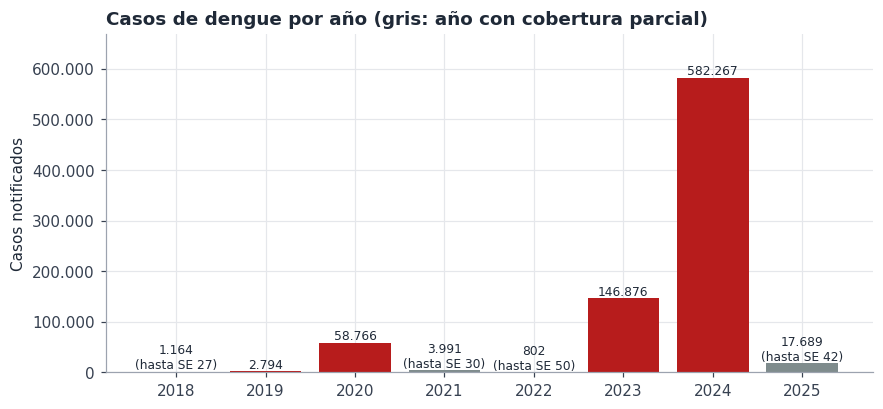

,casos,SE_max,parcial
año,,,
2018,1164,27,True
2019,2794,52,False
2020,58766,53,False
2021,3991,30,True
2022,802,50,True
2023,146876,52,False
2024,582267,52,False
2025,17689,42,True


In [3]:
cobertura = casos.groupby("año").agg(casos=("cant_casos", "sum"), SE_max=("SE", "max"))
cobertura["parcial"] = cobertura["SE_max"] < 52

fig, ax = plt.subplots(figsize=(9, 4))
colores = [GRIS if p else ROJO for p in cobertura["parcial"]]
barras = ax.bar(cobertura.index.astype(str), cobertura["casos"], color=colores)
for barra, (año, fila) in zip(barras, cobertura.iterrows()):
    etiqueta = f"{fila['casos']:,.0f}".replace(",", ".") + (f"\n(hasta SE {fila['SE_max']})" if fila["parcial"] else "")
    ax.text(barra.get_x() + barra.get_width() / 2, fila["casos"], etiqueta, ha="center", va="bottom", fontsize=8)
ax.yaxis.set_major_formatter(miles)
ax.set_ylim(0, cobertura["casos"].max() * 1.15)
ax.set_ylabel("Casos notificados")
ax.set_title("Casos de dengue por año (gris: año con cobertura parcial)")
plt.show()
cobertura

**Hallazgo:** el dengue en Argentina no es una carga constante sino una sucesión de epidemias separadas por años casi sin casos. Las temporadas 2020, 2023 y 2024 concentran el 96,8 % de los 814.349 casos, y la de 2024 sola reúne el 71,5 %: 582.267 casos, casi cuatro veces los de 2023 (146.876). Los años 2018, 2021, 2022, 2025 tienen cobertura parcial y no deben compararse directamente con los demás.

### 2.2 Cuándo ocurre: la curva semanal

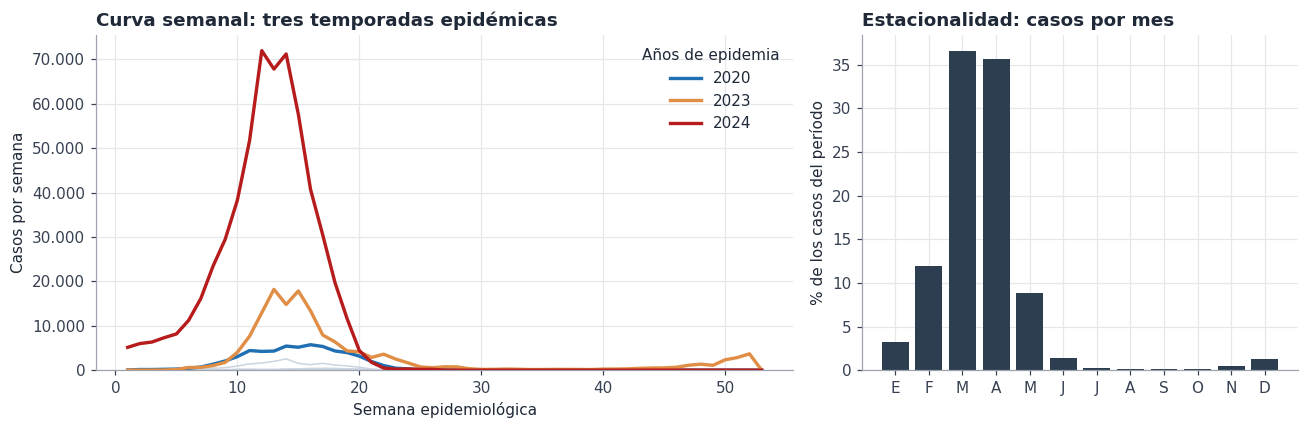

mes,1,2,3,4,5,6,7,8,9,10,11,12
% de casos,3.2,12.0,36.6,35.6,8.8,1.4,0.3,0.1,0.1,0.2,0.5,1.2


In [4]:
nacional = casos.groupby(["año", "SE"])["cant_casos"].sum().unstack("año")
epidemicos = [2020, 2023, 2024]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={"width_ratios": [1.6, 1]})
ax = axes[0]
for año in nacional.columns:
    destacado = año in epidemicos
    ax.plot(nacional.index, nacional[año].fillna(0), lw=2.2 if destacado else 1,
            color={2020: AZUL, 2023: NARANJA, 2024: ROJO}.get(año, "#CBD5E1"),
            label=str(año) if destacado else None, zorder=3 if destacado else 1)
ax.set_xlabel("Semana epidemiológica")
ax.set_ylabel("Casos por semana")
ax.yaxis.set_major_formatter(miles)
ax.set_ylim(bottom=0)
ax.set_title("Curva semanal: tres temporadas epidémicas")
ax.legend(title="Años de epidemia")

por_mes = (casos.assign(mes=(casos["SE_inicio"] + pd.Timedelta(days=3)).dt.month)
           .groupby("mes")["cant_casos"].sum())
por_mes = por_mes / por_mes.sum() * 100
axes[1].bar(por_mes.index, por_mes.values, color=AZUL_OSCURO)
axes[1].set_xticks(range(1, 13), list("EFMAMJJASOND"))
axes[1].set_ylabel("% de los casos del período")
axes[1].set_title("Estacionalidad: casos por mes")
plt.tight_layout()
plt.show()
por_mes.round(1).to_frame("% de casos").T

**Hallazgo:** el dengue tiene una estación muy marcada. Marzo y abril concentran el 72,2 % de los casos del período, y de marzo a mayo se acumula el 81,0 %. Entre julio y octubre casi no hay transmisión. Los picos nacionales cayeron en la semana 12 en 2024, la 13 en 2023 y la 16 en 2020.

### 2.3 Dónde ocurre: incidencia por provincia

La incidencia, casos por 100.000 habitantes, permite comparar provincias de tamaños muy distintos. Se usa la población del censo 2022 (datos provisionales del INDEC).

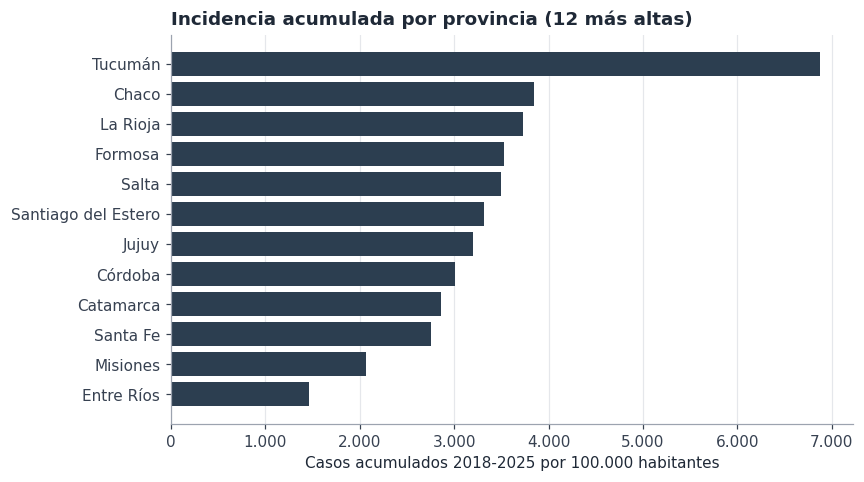

,casos,hab,incidencia_100k
provincia,,,
Tucumán,117185,1703186,6880.0
Chaco,43911,1142963,3842.0
La Rioja,14351,384607,3731.0
Formosa,21384,606041,3528.0
Salta,50347,1440672,3495.0
Santiago del Estero,34932,1054028,3314.0
Jujuy,25521,797955,3198.0
Córdoba,119520,3978984,3004.0
Catamarca,12282,429556,2859.0


In [5]:
prov = (panel.groupby("provincia").agg(casos=("cant_casos", "sum"), hab=("cant_habitantes", "first")))
prov["incidencia_100k"] = prov["casos"] / prov["hab"] * 100_000
prov = prov.sort_values("incidencia_100k", ascending=False)

top = prov.head(12)
fig, ax = plt.subplots(figsize=(8, 4.6))
ax.barh(top.index[::-1], top["incidencia_100k"][::-1], color=AZUL_OSCURO)
ax.set_xlabel("Casos acumulados 2018-2025 por 100.000 habitantes")
ax.xaxis.set_major_formatter(miles)
ax.set_title("Incidencia acumulada por provincia (12 más altas)")
ax.grid(axis="y", visible=False)
plt.show()
prov.assign(incidencia_100k=prov["incidencia_100k"].round(0)).head(12)

**Hallazgo:** Tucumán tiene la incidencia acumulada más alta del país, 6.880 casos por 100.000 habitantes, 1,8 veces la de la segunda (Chaco, 3.842). En casos absolutos, en cambio, el orden es otro: Buenos Aires (171.967) y Córdoba (119.520) encabezan la lista.

### 2.4 Provincias y años a la vez

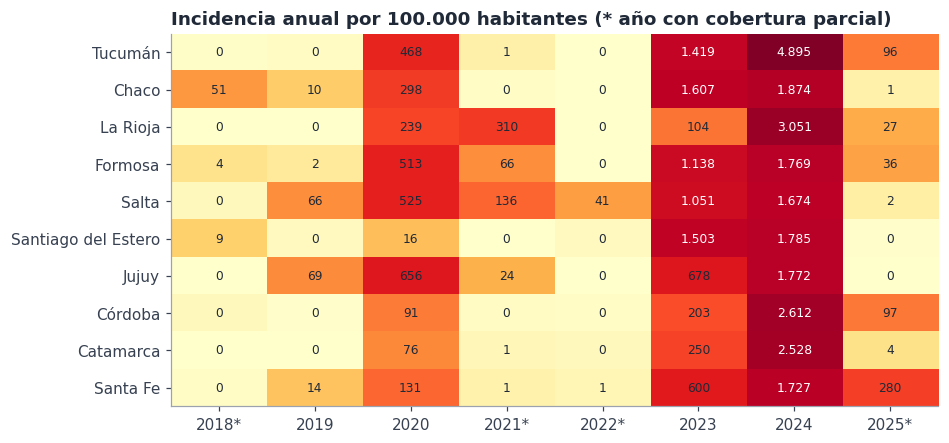

In [6]:
inc_año = (panel.groupby(["provincia", "año"]).agg(casos=("cant_casos", "sum"), hab=("cant_habitantes", "first"))
           .assign(inc=lambda d: d["casos"] / d["hab"] * 100_000)["inc"].unstack("año"))
orden = prov.index[:10]
mat = inc_año.loc[orden]

fig, ax = plt.subplots(figsize=(9, 4.4))
im = ax.imshow(np.log10(1 + mat.values), cmap="YlOrRd", aspect="auto")
ax.set_xticks(range(mat.shape[1]), [f"{a}*" if cobertura.loc[a, "parcial"] else str(a) for a in mat.columns])
ax.set_yticks(range(mat.shape[0]), mat.index)
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        v = mat.values[i, j]
        ax.text(j, i, f"{v:,.0f}".replace(",", "."), ha="center", va="center", fontsize=8,
                color="white" if np.log10(1 + v) > 2.9 else "#1F2937")
ax.grid(False)
ax.set_title("Incidencia anual por 100.000 habitantes (* año con cobertura parcial)")
plt.show()

**Hallazgo:** las epidemias no golpearon a todas las provincias por igual ni en el mismo año. En 2020 el brote fue del norte, con Jujuy, Salta, Formosa y Tucumán como las provincias de mayor incidencia. En 2023 la incidencia más alta pasó a Chaco, Santiago del Estero, Tucumán y Formosa. En 2024 el brote alcanzó al centro del país: La Rioja, Córdoba, Catamarca y Santa Fe registraron incidencias que no habían tenido en los años anteriores. El área afectada se fue corriendo hacia el sur con cada temporada fuerte.

### 2.5 En quiénes: grupos de edad

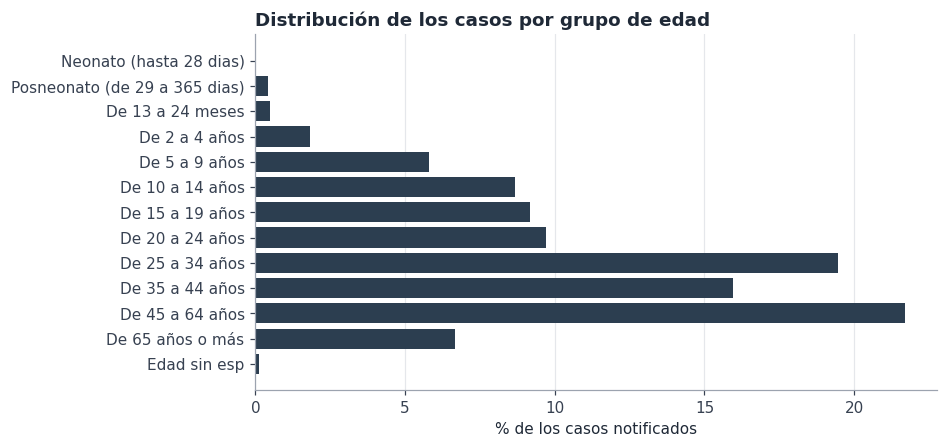

,cant_casos,% de casos
grupo_edad,,
Neonato (hasta 28 dias),296,0.0
Posneonato (de 29 a 365 dias),3545,0.4
De 13 a 24 meses,4000,0.5
De 2 a 4 años,14737,1.8
De 5 a 9 años,47175,5.8
De 10 a 14 años,70598,8.7
De 15 a 19 años,74726,9.2
De 20 a 24 años,79101,9.7
De 25 a 34 años,158390,19.4


In [7]:
edad = casos.groupby(["id_grupo_edad", "grupo_edad"])["cant_casos"].sum().reset_index()
edad["% de casos"] = edad["cant_casos"] / edad["cant_casos"].sum() * 100

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.barh(edad["grupo_edad"][::-1], edad["% de casos"][::-1], color=AZUL_OSCURO)
ax.set_xlabel("% de los casos notificados")
ax.set_title("Distribución de los casos por grupo de edad")
ax.grid(axis="y", visible=False)
plt.show()
edad[["grupo_edad", "cant_casos", "% de casos"]].round(1).set_index("grupo_edad")

**Hallazgo:** los adultos de 25 a 64 años reúnen el 57,1 % de los casos. Los menores de 15 años suman el 17,2 % y los mayores de 65, el 6,7 %. Hay que leer esta distribución con cuidado: son porcentajes de casos *notificados*, no una tasa por edad. Los grupos tienen poblaciones muy distintas y la fuente no trae la población por grupo, de modo que no se puede decir cuál es el más afectado en términos de riesgo.

## 3. El clima frente a los casos

### 3.1 Preparación del clima

El análisis temporal se hace en las **14 provincias con al menos 10.000 casos** en el período. En las demás, la transmisión es escasa, la mayor parte de las semanas no tiene casos y no hay señal que correlacionar. Eso deja 5.012 observaciones provincia-semana.

In [8]:
# Provincias con transmisión relevante: al menos 10.000 casos en el período
relevantes = prov[prov["casos"] >= 10_000].index.tolist()
print(len(relevantes), "provincias:", ", ".join(sorted(relevantes)))

c = clima.copy()
c["fecha"] = pd.to_datetime(c["año"].astype(str) + "-W" + c["SE"].astype(str).str.zfill(2) + "-1", format="%G-W%V-%u")
c = c.sort_values(["provincia", "fecha"]).reset_index(drop=True)
VARS = {"temp_media": "Temperatura media", "precip_mm": "Precipitación semanal",
        "hum_rel": "Humedad relativa", "dias_lluvia": "Días con lluvia (> 1 mm)"}

14 provincias: Buenos Aires, Catamarca, Chaco, Corrientes, Córdoba, Entre Ríos, Formosa, Jujuy, La Rioja, Misiones, Salta, Santa Fe, Santiago del Estero, Tucumán


### 3.2 Primera mirada: dos curvas con la misma forma

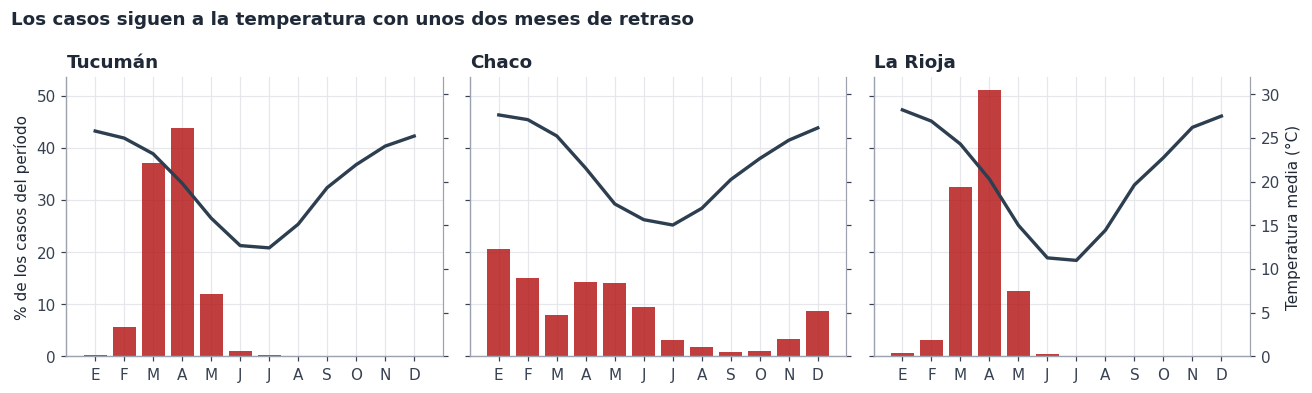

In [9]:
# Un ciclo anual: la temperatura llega al máximo en enero-febrero y los casos, dos meses después
prov3 = prov.index[:3]
mes_clima = pd.read_csv(PROCESSED / "clima_provincia_mensual.csv")
casos_mes = (panel.assign(mes=(panel["SE_inicio"] + pd.Timedelta(days=3)).dt.month)
             .groupby(["provincia", "mes"])["cant_casos"].sum().unstack("mes"))

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharey=True)
for ax, nombre in zip(axes, prov3):
    share = casos_mes.loc[nombre] / casos_mes.loc[nombre].sum() * 100
    ax.bar(share.index, share.values, color=ROJO, alpha=0.85, label="% de casos")
    ax2 = ax.twinx()
    temp = mes_clima[mes_clima["provincia"] == nombre].groupby("mes")["temp_media"].mean()
    ax2.plot(temp.index, temp.values, color=AZUL_OSCURO, lw=2.2, label="Temperatura media")
    ax2.set_ylim(0, 32)
    ax2.grid(False)
    ax2.spines["right"].set_visible(True)
    ax.set_title(nombre)
    ax.set_xticks(range(1, 13), list("EFMAMJJASOND"))
    if ax is axes[-1]:
        ax2.set_ylabel("Temperatura media (°C)")
    else:
        ax2.set_yticklabels([])
axes[0].set_ylabel("% de los casos del período")
fig.suptitle("Los casos siguen a la temperatura con unos dos meses de retraso", x=0.01, ha="left", fontweight="bold")
plt.tight_layout()
plt.show()

A simple vista la relación es evidente: los casos se concentran en el otoño, unos dos meses después de los máximos de temperatura. Es la imagen que sostendría cualquier explicación del tipo "el calor trae el dengue". Pero antes de aceptarla hay que hacerse una pregunta: ¿esa semejanza refleja una relación entre el clima y los brotes, o simplemente que **ambas series siguen el calendario**?

La temperatura sube cada verano y el dengue también, año tras año, tanto en un año con epidemia como en uno sin ella. Cualquier variable que tenga un ciclo anual se va a parecer al dengue por ese solo hecho.

### 3.3 Correlación con rezago, con y sin el ciclo anual

El dengue no responde al clima de la misma semana: el mosquito necesita tiempo para reproducirse, el virus para incubarse y las personas para consultar y ser notificadas. Por eso se calcula la correlación entre los casos de una semana y el clima de hasta 16 semanas antes.

El cálculo se hace de dos formas:

- **Bruta:** tal cual, con el ciclo anual incluido.
- **Sin ciclo anual:** a cada valor se le resta el promedio típico de su provincia en esa semana del año (una *anomalía*). Queda solo la parte que se aparta de lo habitual, que es lo que podría explicar por qué un año tuvo más casos que otro.

Se usa la correlación de Spearman, que no supone una relación lineal y tolera mejor la asimetría de los casos. Los casos se transforman con `log(1 + incidencia)`, porque la incidencia tiene colas muy largas.

In [10]:
LAGS = list(range(0, 17))
nuevas = {}
for v in VARS:
    c[v + "_an"] = c[v] - c.groupby(["provincia", "SE"])[v].transform("mean")    # anomalía: se quita el ciclo anual típico
    for k in LAGS:
        nuevas[f"{v}_l{k}"] = c.groupby("provincia")[v].shift(k)
        nuevas[f"{v}_an_l{k}"] = c.groupby("provincia")[v + "_an"].shift(k)
c = pd.concat([c, pd.DataFrame(nuevas)], axis=1)

base = panel[["provincia", "año", "SE", "cant_casos", "incidencia_100k"]].merge(c, on=["provincia", "año", "SE"], how="left")
base["y"] = np.log1p(base["incidencia_100k"])
base["y_an"] = base["y"] - base.groupby(["provincia", "SE"])["y"].transform("mean")
base = base[base["provincia"].isin(relevantes)]
print(f"Observaciones provincia-semana usadas: {len(base):,}".replace(",", "."))

Observaciones provincia-semana usadas: 5.012


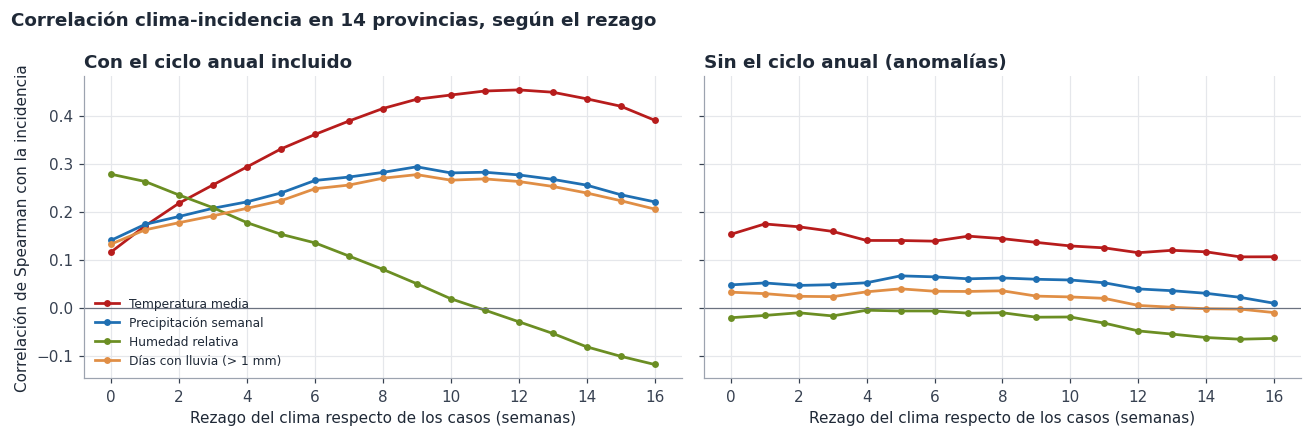

,rezago,bruta,sin_estacionalidad
variable,,,
Días con lluvia (> 1 mm),9,0.28,0.02
Humedad relativa,0,0.28,-0.02
Precipitación semanal,9,0.29,0.06
Temperatura media,12,0.45,0.11


In [11]:
filas = []
for v in VARS:
    for k in LAGS:
        bruta = base[[f"{v}_l{k}", "y"]].dropna().corr(method="spearman").iloc[0, 1]
        sin_est = base[[f"{v}_an_l{k}", "y_an"]].dropna().corr(method="spearman").iloc[0, 1]
        filas.append((v, k, bruta, sin_est))
rho = pd.DataFrame(filas, columns=["variable", "rezago", "bruta", "sin_estacionalidad"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
colores = {"temp_media": ROJO, "precip_mm": AZUL, "hum_rel": VERDE, "dias_lluvia": NARANJA}
for ax, col, titulo in zip(axes, ["bruta", "sin_estacionalidad"],
                           ["Con el ciclo anual incluido", "Sin el ciclo anual (anomalías)"]):
    for v, nombre in VARS.items():
        d = rho[rho["variable"] == v]
        ax.plot(d["rezago"], d[col], marker="o", ms=3.5, lw=1.8, color=colores[v], label=nombre)
    ax.axhline(0, color="#6B7280", lw=0.8)
    ax.set_xlabel("Rezago del clima respecto de los casos (semanas)")
    ax.set_title(titulo)
axes[0].set_ylabel("Correlación de Spearman con la incidencia")
axes[0].legend(fontsize=8)
fig.suptitle("Correlación clima-incidencia en 14 provincias, según el rezago", x=0.01, ha="left", fontweight="bold")
plt.tight_layout()
fig.savefig(IMAGES / "analisis-clima-rezago.png")
plt.show()

resumen_rho = rho.loc[rho.groupby(["variable"])["bruta"].apply(lambda s: s.abs().idxmax())]
resumen_rho = resumen_rho.assign(variable=resumen_rho["variable"].map(VARS))
resumen_rho.round(2).set_index("variable")

**Hallazgo central:** la correlación bruta de la temperatura llega a ρ = 0,45 con un rezago de 12 semanas, que es un valor moderado y aparentemente interesante. Pero al quitar el ciclo anual se desploma: para la temperatura queda entre ρ = 0,11 y 0,17, sin un rezago que se destaque, y para las demás variables es prácticamente cero (entre −0,07 y 0,07).

Esto significa que casi toda la correlación aparente se debe a que la temperatura y el dengue comparten estacionalidad. Una vez descontada, el clima de una semana dice muy poco sobre si esa semana tendrá más o menos casos de lo esperable para la época. La humedad y la lluvia no aportan nada que no esté ya en el calendario: su correlación bruta máxima (0,28 y 0,29) desaparece por completo al quitar el ciclo.

**Lo que sí se puede afirmar** es que el clima explica el *cuándo*: el dengue ocurre en la estación cálida y húmeda, con un desfase de semanas. **Lo que no se sostiene** es que las variaciones semanales del clima predigan el tamaño de un brote.

### 3.4 Entre temporadas: ¿los veranos cálidos produjeron más dengue?

La correlación semanal puede perder lo que sí importa a escala de temporada. Para chequearlo se compara, año por año, la anomalía de temperatura del verano (el promedio de las provincias respecto de su clima típico de 2018–2025) con la incidencia de la temporada, tomando de la semana 1 a la 26. Cada punto del gráfico es un año.

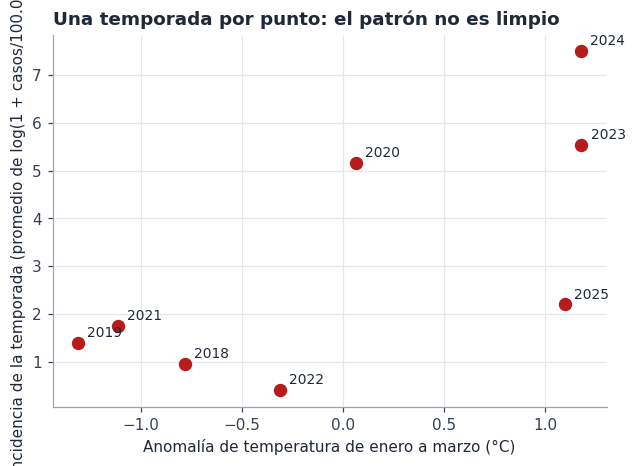

,anom_temp,anom_precip,lg
año,,,
2018,-0.78,-7.52,0.95
2019,-1.31,34.36,1.39
2020,0.06,-1.01,5.15
2021,-1.11,9.73,1.75
2022,-0.31,-0.05,0.41
2023,1.18,-27.04,5.54
2024,1.18,1.77,7.49
2025,1.10,-10.24,2.20


In [12]:
# Entre temporadas: ¿los veranos más cálidos coincidieron con más dengue?
temporada = (panel[panel["SE"] <= 26].groupby(["provincia", "año"])
             .agg(casos=("cant_casos", "sum"), hab=("cant_habitantes", "first")).reset_index())
temporada["inc"] = temporada["casos"] / temporada["hab"] * 100_000

mes = pd.read_csv(PROCESSED / "clima_provincia_mensual.csv")
mes["anom_t"] = mes["temp_media"] - mes.groupby(["provincia", "mes"])["temp_media"].transform("mean")
mes["anom_p"] = mes["precip_mm"] - mes.groupby(["provincia", "mes"])["precip_mm"].transform("mean")

def ventana(meses):
    w = mes[mes["mes"].isin(meses)]
    return w.groupby(["provincia", "año"]).agg(anom_t=("anom_t", "mean"), anom_p=("anom_p", "mean")).reset_index()

anio = (temporada.merge(ventana([1, 2, 3]), on=["provincia", "año"])
        .query("provincia in @relevantes")
        .assign(lg=lambda d: np.log1p(d["inc"]))
        .groupby("año").agg(anom_temp=("anom_t", "mean"), anom_precip=("anom_p", "mean"), lg=("lg", "mean")))

fig, ax = plt.subplots(figsize=(6.5, 4.4))
ax.scatter(anio["anom_temp"], anio["lg"], s=60, color=ROJO, zorder=3)
for año, f in anio.iterrows():
    ax.annotate(str(año), (f["anom_temp"], f["lg"]), textcoords="offset points", xytext=(6, 4), fontsize=9)
ax.set_xlabel("Anomalía de temperatura de enero a marzo (°C)")
ax.set_ylabel("Incidencia de la temporada (promedio de log(1 + casos/100.000))")
ax.set_title("Una temporada por punto: el patrón no es limpio")
plt.show()
anio.round(2)

Hay una pista: los dos veranos de mayor dengue, 2023 y 2024, fueron también de los más cálidos, con una anomalía de unos +1,2 °C. Pero el patrón no es limpio. **2020** tuvo una epidemia importante con un verano de temperatura normal (0,1 °C), y **2025** tuvo un verano tan cálido como los de 2023–2024 (+1,1 °C) y tuvo mucho menos dengue. Un verano cálido no alcanza para que haya epidemia.

Con solo 8 temporadas, además, cualquier correlación es frágil. Se comprueba cuánto depende de cómo se defina el verano:

In [13]:
# Con 8 temporadas la correlación es frágil: se comprueba qué tanto cambia si se cambia la ventana de meses
res = []
for etiqueta, meses in {"enero a marzo": [1, 2, 3], "diciembre a febrero": [12, 1, 2], "enero a febrero": [1, 2]}.items():
    t = (temporada.merge(ventana(meses), on=["provincia", "año"]).query("provincia in @relevantes")
         .assign(lg=lambda d: np.log1p(d["inc"]))
         .groupby("año").agg(anom_t=("anom_t", "mean"), lg=("lg", "mean")))
    res.append((etiqueta, t.corr(method="spearman").iloc[0, 1], len(t)))
pd.DataFrame(res, columns=["ventana de meses", "correlación de Spearman", "temporadas"]).round(2).set_index("ventana de meses")

,correlación de Spearman,temporadas
ventana de meses,,
enero a marzo,0.74,8
diciembre a febrero,0.26,8
enero a febrero,0.50,8


La correlación entre temporadas va de 0,26 a 0,74 según la ventana de meses elegida. Ese rango es una señal de que **ocho puntos no alcanzan para sostener una conclusión**: con otra definición de verano, el resultado cambia de moderado a casi nulo. Reportar solo el valor más favorable (0,74) sería engañoso.

### 3.5 Entre provincias: el dónde

Hasta acá se midió cómo cambia el dengue en el tiempo dentro de cada provincia. Falta la otra mirada: **entre provincias**. ¿Las más cálidas son también las de mayor incidencia? Es la correlación que muestra el dashboard: una fila por provincia, con la temperatura media del período y la incidencia semanal media, contando las semanas sin casos como cero.

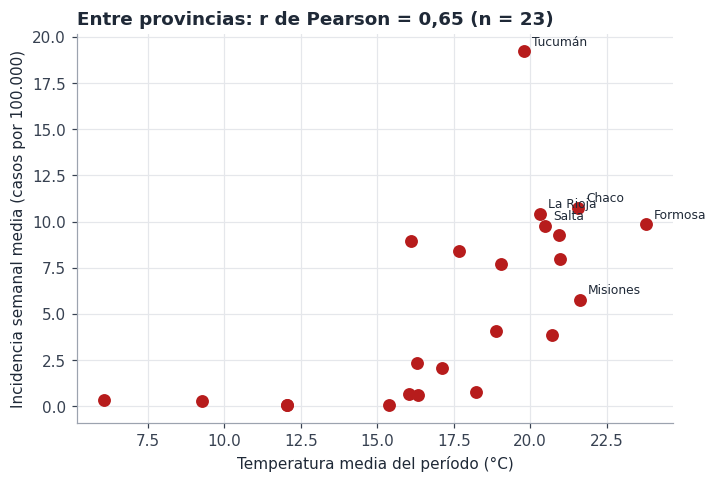

,Pearson,Spearman
23 provincias,0.65,0.78
14 provincias con dengue,0.24,0.28


In [14]:
# Una fila por provincia: temperatura media del período e incidencia semanal media (las semanas sin casos cuentan como cero)
por_prov = (panel.groupby("provincia")
            .agg(temp=("temp_media", "mean"), inc=("incidencia_100k", "mean"), casos=("cant_casos", "sum")))
r_pearson = por_prov["temp"].corr(por_prov["inc"])
r_spearman = por_prov["temp"].corr(por_prov["inc"], method="spearman")

# Solo entre las provincias donde el dengue circuló (las 14 con al menos 10.000 casos)
con_dengue = por_prov.loc[relevantes]
r_pearson_14 = con_dengue["temp"].corr(con_dengue["inc"])
r_spearman_14 = con_dengue["temp"].corr(con_dengue["inc"], method="spearman")

fig, ax = plt.subplots(figsize=(7, 4.6))
ax.scatter(por_prov["temp"], por_prov["inc"], s=55, color=ROJO, zorder=3)
for nombre, f in por_prov.iterrows():
    if nombre in por_prov["inc"].nlargest(5).index or nombre in por_prov["temp"].nlargest(3).index:
        ax.annotate(nombre, (f["temp"], f["inc"]), textcoords="offset points", xytext=(5, 4), fontsize=8)
ax.set_xlabel("Temperatura media del período (°C)")
ax.set_ylabel("Incidencia semanal media (casos por 100.000)")
ax.set_title(f"Entre provincias: r de Pearson = {r_pearson:.2f} (n = {len(por_prov)})".replace(".", ","))
plt.show()
pd.DataFrame({"Pearson": [r_pearson, r_pearson_14], "Spearman": [r_spearman, r_spearman_14]},
             index=[f"23 provincias", f"{len(con_dengue)} provincias con dengue"]).round(2)

**Hallazgo:** entre las 23 provincias la correlación es alta (r de Pearson = 0,65, Spearman = 0,78): las provincias más cálidas son, en general, las que tuvieron dengue. Es el gradiente norte-sur que ya se veía en la incidencia por provincia.

Pero hay que leerla con cuidado, por tres razones:

- **La mayor parte la explica un corte, no una gradación.** Las 9 provincias donde casi no hubo transmisión (menos de 10.000 casos) tienen una temperatura media de 18,2 °C o menos. Si se mira solo a las 14 provincias con dengue, la correlación baja a r = 0,24 (Spearman = 0,28). Es decir, el clima separa bien donde hay dengue de donde no hay, pero ordena mucho peor *cuánto* hay entre las que sí tienen.
- **No es la más cálida la más afectada.** Tucumán tiene la mayor incidencia (19,2 casos semanales por 100.000) con 19,8 °C, mientras que Formosa, la más cálida (23,8 °C), tiene 9,9.
- **Son 23 puntos y una relación entre grupos.** La temperatura se confunde con la latitud, la presencia del mosquito, la urbanización y la historia de circulación del virus. Lo que vale para el conjunto de provincias no tiene por qué valer dentro de cada una.

## 4. Conclusiones
1. **El dengue en Argentina se concentra en pocas temporadas.** Las de 2020, 2023 y 2024 reúnen el 96,8 % de los casos, y la de 2024 sola, el 71,5 %.
2. **La estación es muy marcada**: marzo y abril concentran el 72,2 % de los casos, con un desfase de unos dos meses respecto del máximo de temperatura.
3. **El clima explica el cuándo y, en parte, el dónde; no el cuánto.** La correlación bruta de la temperatura con la incidencia (ρ = 0,45) corresponde casi por completo al ciclo anual: sin él queda en ρ ≈ 0,14. Entre provincias la correlación es alta (r = 0,65), pero la mayor parte es el corte entre el norte cálido, con dengue, y el sur frío, sin él: entre las 14 provincias con dengue baja a r = 0,24.
4. **Entre temporadas, el calor no es suficiente.** Hubo una epidemia con un verano normal (2020) y un verano cálido sin epidemia (2025).
5. **Con 8 temporadas no se pueden sacar conclusiones fuertes** sobre el tamaño de un brote.

Es una conclusión menos vistosa que "el clima predice el dengue", pero es la que respalda el dato. Lo que determina el tamaño de una epidemia depende probablemente de factores que este análisis no incluye: la inmunidad previa de la población, qué serotipo circula, la presencia del vector y la introducción del virus desde países vecinos.

El siguiente notebook pone esta conclusión a prueba de otra manera: si el clima sirve para anticipar casos, un modelo de pronóstico con clima debería superar a uno que solo conoce los casos previos.